In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df = df.drop(['id'],axis=1)

In [4]:
df.info

<bound method DataFrame.info of        health_condition  sleep_duration  heart_rate    bmi  \
0             unhealthy            5.22        70.6  25.66   
1               at-risk            5.53        71.3  25.84   
2             unhealthy            5.29        75.4  24.54   
3             unhealthy            4.70        77.2  23.13   
4               at-risk            7.23        73.4  28.44   
...                 ...             ...         ...    ...   
690083          at-risk            6.31        69.7  24.11   
690084          at-risk            5.78        54.0  26.36   
690085              fit            7.64        85.7  21.91   
690086          at-risk            6.74        73.0  18.73   
690087          at-risk            5.55        69.3  24.38   

        calorie_expenditure  step_count  exercise_duration  water_intake  \
0                    2174.0      1326.0               19.8          1.86   
1                    1966.0      9891.0               49.9          1.2

In [5]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [6]:
df.isnull().sum()

health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [7]:
df.shape

(690088, 14)

In [8]:
overweight = df['bmi'] > 25.0 # from standard BMI 
print(f"% fraction of overweight to total = {len(overweight) / df['bmi'].sum() * 100:.1f}")

% fraction of overweight to total = 4.4


In [9]:
df.groupby('gender')['step_count'].mean()

gender
female    8610.090299
male      8630.200908
other     8604.011477
Name: step_count, dtype: float64

In [10]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
print(missing_percentages)

health_condition            0.000000
sleep_duration             11.012943
heart_rate                  1.135073
bmi                         2.013946
calorie_expenditure         7.658878
step_count                  2.016554
exercise_duration           1.000017
water_intake                6.300211
diet_type                   1.000017
stress_level               12.000064
sleep_quality               8.452690
physical_activity_level     5.306715
smoking_alcohol             4.141791
gender                      3.097141
dtype: float64


In [11]:
df = df.dropna(subset=['heart_rate','bmi','calorie_expenditure','step_count','exercise_duration','water_intake','diet_type','sleep_quality','physical_activity_level','smoking_alcohol','gender'])

<Axes: xlabel='calorie_expenditure', ylabel='step_count'>

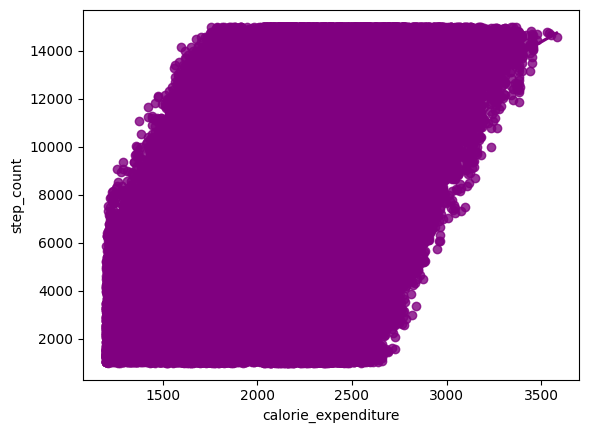

In [12]:
sns.regplot(data=df, x = 'calorie_expenditure', y='step_count', color='purple')

<Axes: xlabel='calorie_expenditure', ylabel='Count'>

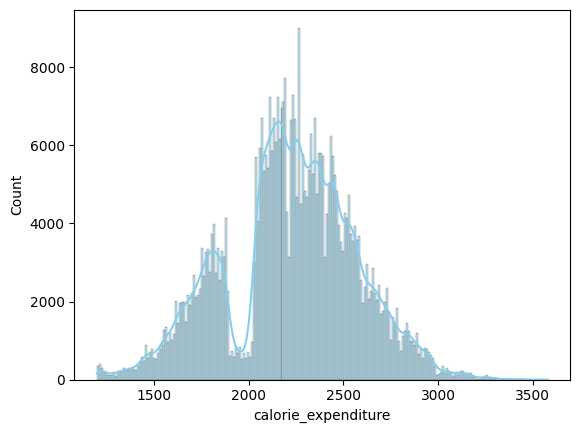

In [13]:
sns.histplot(data=df, x='calorie_expenditure', kde=True, color='skyblue')

<Axes: >

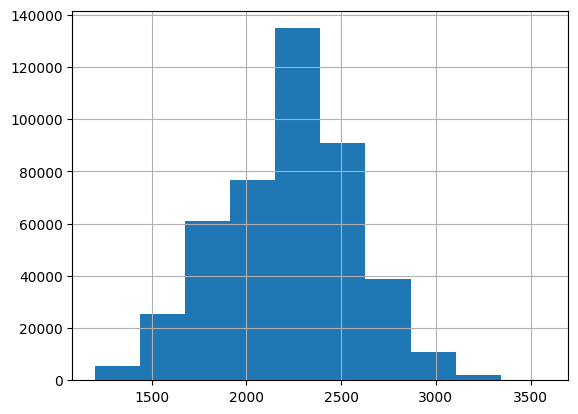

In [14]:
df['calorie_expenditure'].hist()

In [15]:
df['health_condition'].value_counts()

health_condition
at-risk      382939
unhealthy     37771
fit           25516
Name: count, dtype: int64

In [16]:
df.describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,397125.000000,446226.000000,446226.000000,446226.000000,446226.000000,446226.000000,446226.000000
mean,6.981701,75.094142,22.979138,2226.104611,8615.796321,38.744105,2.188198
std,1.215657,8.171941,2.482015,347.398918,3932.074006,14.744100,0.518411
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.140000,69.400000,21.310000,2053.000000,5386.000000,29.100000,1.840000
50%,6.970000,75.100000,22.980000,2240.000000,8861.000000,39.400000,2.170000
75%,7.800000,80.700000,24.660000,2456.000000,12115.000000,49.400000,2.490000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [17]:
print(df['calorie_expenditure'].var())

120686.00796184443


<Axes: >

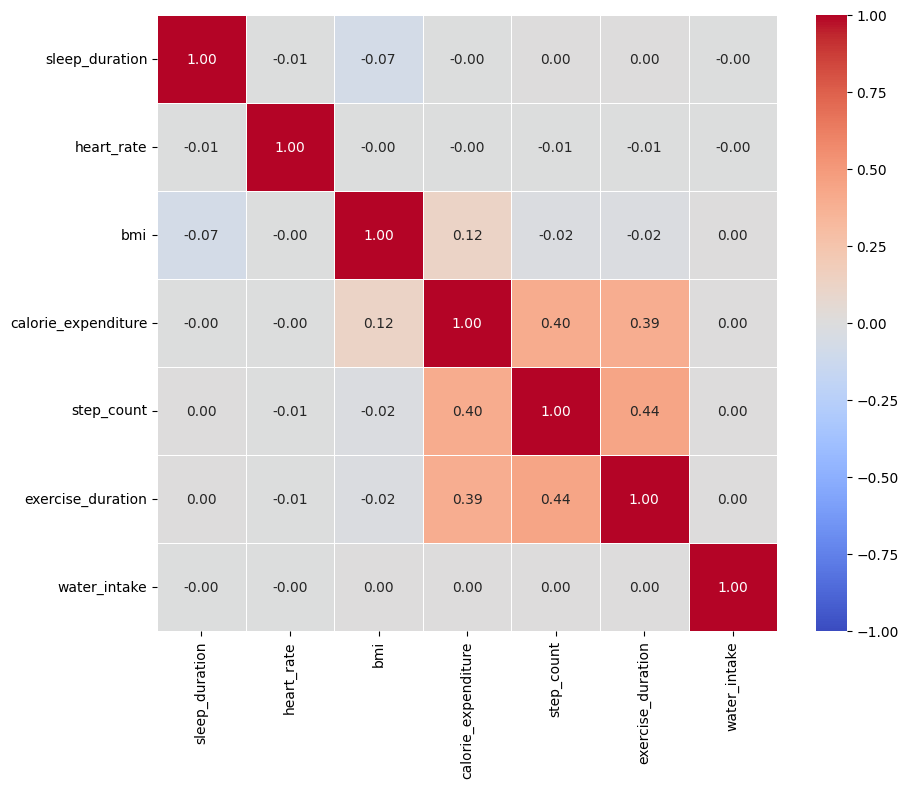

In [18]:
num_df = df.select_dtypes(include=['number'])
corr_matrx = num_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrx,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidths = 0.5,
    vmin =-1,
    vmax=1)
    

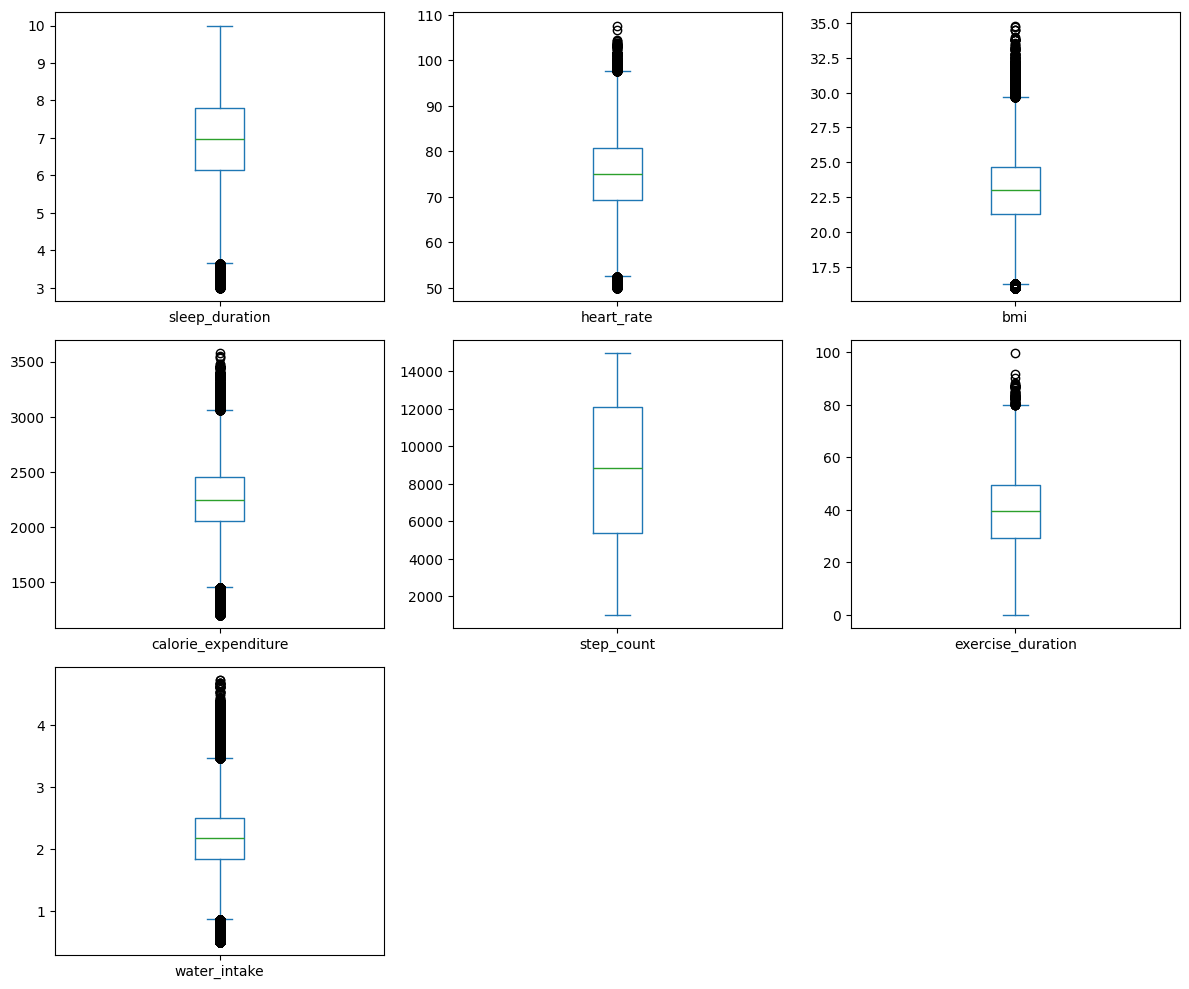

In [19]:
cols = df.select_dtypes(include=['number']).columns

df[cols].plot(
    kind='box', 
    subplots=True, 
    layout=(3, 3), 
    figsize=(12, 10), 
    sharey=False  # Keeps scales independent for all 7 features
)

plt.tight_layout()
plt.show()

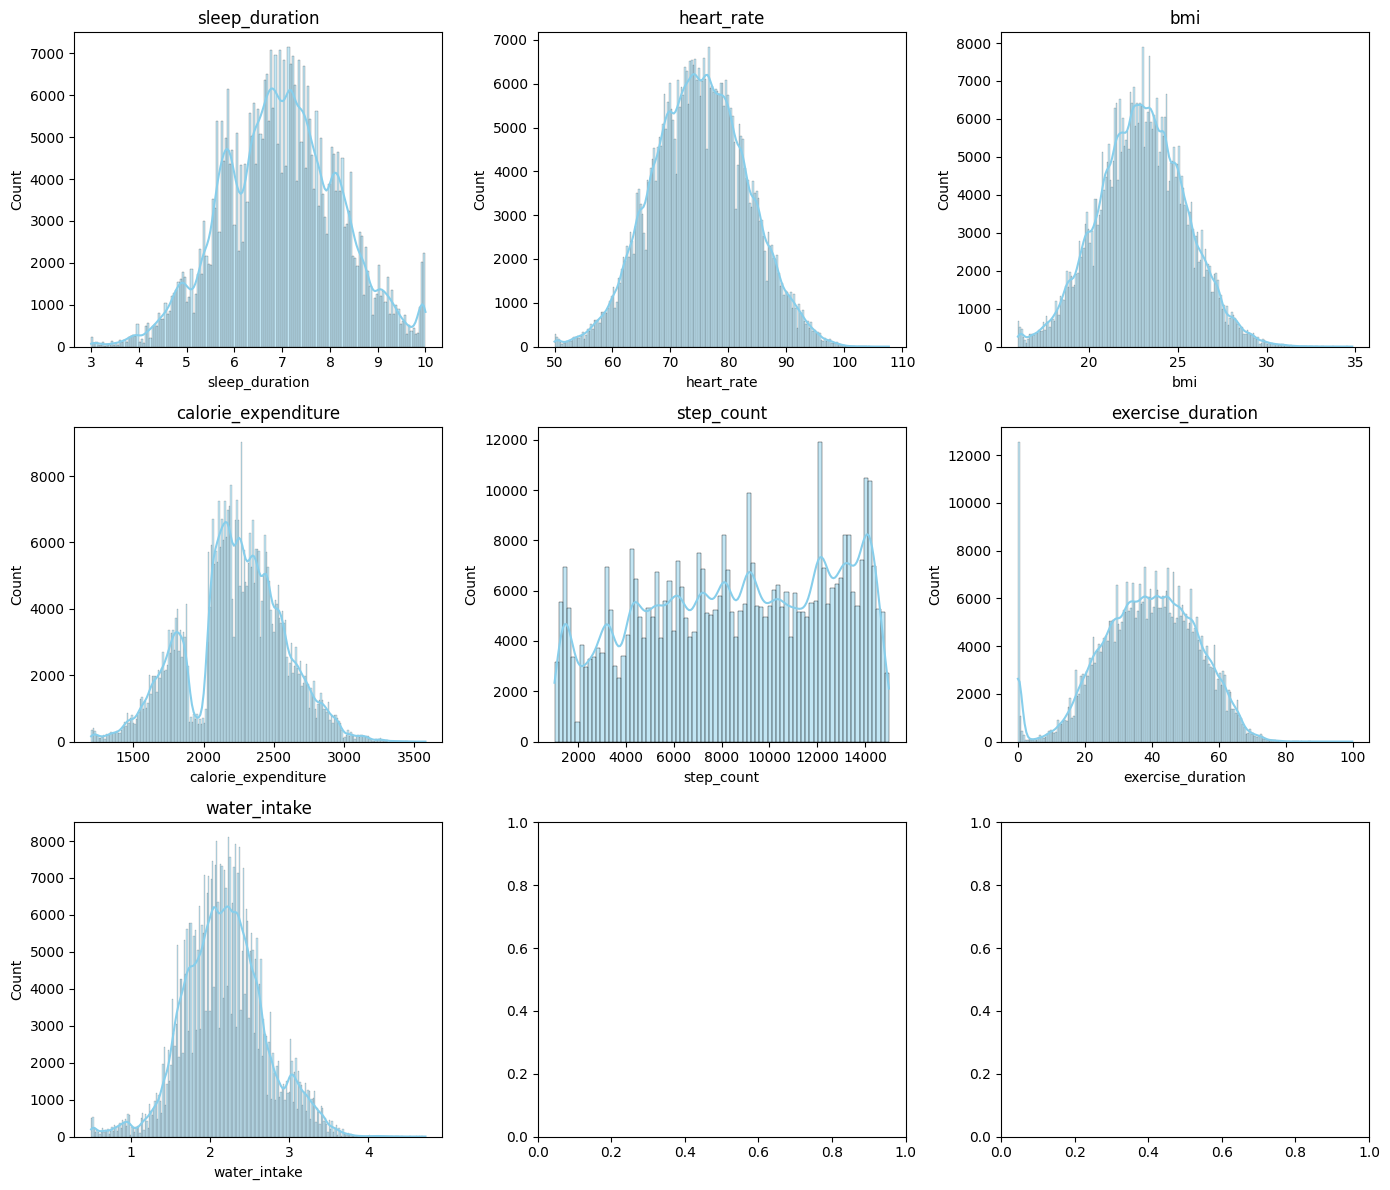

In [20]:
num_cols = df.select_dtypes(include=['number']).columns

fig, axs = plt.subplots(3,3,figsize=(14,12))
axs = axs.flatten()

for i in range(len(num_cols)):
    sns.histplot(data = df, x = num_cols[i], kde=True, ax=axs[i], color='skyblue')
    axs[i].set_title(num_cols[i])

plt.tight_layout()

In [21]:
cat_cols = ['sleep_duration', 'stress_level']
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

C:\Users\USER\AppData\Local\Temp\ipykernel_20092\3061422400.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [22]:
df.head()

,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male


In [23]:
df.isnull().sum()

health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

In [25]:
df.to_csv('final_health_data',index=False)